<a href="https://colab.research.google.com/github/Akira006/noise-aware-federated-learning-dr/blob/main/Notebook/pytorch_exp1_centralized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 1 — Centralized Training (PyTorch EfficientNetB0)

**Paradigm:** Centralized — all datasets pooled  
**Framework:** PyTorch + torchvision  
**Model:** EfficientNetB0 (ImageNet pretrained, torchvision)

> **Comparison note vs TF version:**  
> - PyTorch EfficientNetB0 expects input `[0,1]` normalized with ImageNet mean/std — no double-rescaling bug  
> - Training loop is explicit (manual forward/backward pass) vs Keras `.fit()`  
> - Same SEED=42, NOISY_TEST_SEED=123, same split, same hyperparams for fair comparison

| Config | Value |
|--------|-------|
| Datasets | DDR + EyePACS + APTOS (pooled) |
| Split | 70:15:15 stratified per-client lalu di-pool |
| Stage 1 | 20 epochs frozen backbone |
| Stage 2 | 20 epochs unfreeze top-10 layers |
| Optimizer | Adam lr=1e-4, batch=32 |
| Loss | CrossEntropyLoss + class weights (balanced) |

## 1. GPU Check

In [1]:
!nvidia-smi

Sat May  9 06:32:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   34C    P0             56W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 2. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Install & Imports

In [3]:
# torchvision sudah tersedia di Colab, tapi pastikan versi terbaru
!pip install -q torchvision --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 106.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 112.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5

In [4]:
import os, json, random, time, gc, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score, roc_curve, auc,
    cohen_kappa_score
)
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import EfficientNet_B0_Weights

print(f"PyTorch   : {torch.__version__}")
print(f"CUDA      : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU       : {torch.cuda.get_device_name(0)}")
    print(f"VRAM      : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device    : {DEVICE}")

PyTorch   : 2.11.0+cu130
CUDA      : True
GPU       : NVIDIA A100-SXM4-80GB
VRAM      : 85.1 GB
Device    : cuda


## 4. Configuration

In [5]:
# ── REPRODUCIBILITY ───────────────────────────────────────────────
SEED            = 42
NOISY_TEST_SEED = 123
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# ── MODEL & EXPERIMENT ────────────────────────────────────────────
MODEL_NAME      = "PyTorch_EfficientNetB0"
EXPERIMENT_NAME = "exp1_centralized"

# ── TRAINING ──────────────────────────────────────────────────────
IMG_SIZE        = 224
NUM_CLASSES     = 5
BATCH_SIZE      = 32
LR              = 1e-4
EPOCHS_S1       = 20
EPOCHS_S2       = 20
UNFREEZE_N      = 10    # unfreeze last N layers of backbone
DROPOUT         = 0.4
PATIENCE        = 5     # EarlyStopping patience

# ── IMAGENET NORMALIZATION (PyTorch standard) ──────────────────────
# torchvision EfficientNetB0 expects [0,1] normalized with ImageNet stats
# Berbeda dari TF Keras yang expects [0,255] dengan internal rescaling
IMAGENET_MEAN   = [0.485, 0.456, 0.406]
IMAGENET_STD    = [0.229, 0.224, 0.225]

# ── NOISE PARAMS ──────────────────────────────────────────────────
NS_MIN, NS_MAX  = 0.01, 0.05
BL_MIN, BL_MAX  = 1.0,  3.0
BR_DELTA        = 0.2
CT_LOW, CT_HIGH = 0.7,  1.3

CLASS_NAMES     = ["No DR","Mild","Moderate","Severe","Proliferative"]
CLIENT_NAMES    = ["DDR","EyePACS","APTOS"]

# ── PATHS ─────────────────────────────────────────────────────────
PROJECT  = "/content/drive/MyDrive/Binus/Semester_4/Research_Methodology"
DS_BASE  = "/content/drive/MyDrive/S-Class/Orion/OrionFL"

APTOS_NPZ = f"{DS_BASE}/APTOS_2019/preprocessed/orion_dr_224.npz"
DDR_NPZ   = f"{DS_BASE}/DDR_Dataset/DDR_dataset_224.npz"
EYE_NPZ   = f"{DS_BASE}/EyePACS_Dataset/training/EyePACS_dataset_224.npz"
EYE_CSV   = f"{DS_BASE}/EyePACS_Dataset/training/trainLabels.csv"

RES      = f"{PROJECT}/Result/{MODEL_NAME}/{EXPERIMENT_NAME}"
MDL_DIR  = f"{RES}/models"
LOG_DIR  = f"{RES}/logs"
FIG_DIR  = f"{RES}/figures"
for d in [MDL_DIR, LOG_DIR, FIG_DIR]: os.makedirs(d, exist_ok=True)

print(f"Model      : {MODEL_NAME}")
print(f"Device     : {DEVICE}")
print(f"Results    : {RES}")

Model      : PyTorch_EfficientNetB0
Device     : cuda
Results    : /content/drive/MyDrive/Binus/Semester_4/Research_Methodology/Result/PyTorch_EfficientNetB0/exp1_centralized


## 5. Load Datasets

In [6]:
def to01(X):
    """Normalize to [0,1]. PyTorch EfficientNet expects [0,1] input
    (then we apply ImageNet mean/std normalization in transforms)."""
    X = X.astype(np.float32)
    return X / 255.0 if X.max() > 1.0 else X

print("Loading DDR...")
d = np.load(DDR_NPZ, allow_pickle=True)
X_ddr, y_ddr = to01(d["X"]), d["y"].astype(np.int64)
print(f"  {X_ddr.shape} | range=[{X_ddr.min():.2f},{X_ddr.max():.2f}]")

print("Loading EyePACS...")
d = np.load(EYE_NPZ, allow_pickle=True)
X_eye = to01(d["images"])
y_eye = pd.read_csv(EYE_CSV)["level"].values.astype(np.int64)
assert len(X_eye) == len(y_eye)
print(f"  {X_eye.shape} | range=[{X_eye.min():.2f},{X_eye.max():.2f}]")

print("Loading APTOS...")
d = np.load(APTOS_NPZ, allow_pickle=True)
X_apt, y_apt = to01(d["images"]), d["labels"].astype(np.int64)
print(f"  {X_apt.shape} | range=[{X_apt.min():.2f},{X_apt.max():.2f}]")

for name, y in zip(CLIENT_NAMES, [y_ddr, y_eye, y_apt]):
    dist = dict(zip(*np.unique(y, return_counts=True)))
    print(f"  {name}: {dist}")

Loading DDR...
  (12522, 224, 224, 3) | range=[0.00,1.00]
Loading EyePACS...
  (35126, 224, 224, 3) | range=[0.00,1.00]
Loading APTOS...
  (3662, 224, 224, 3) | range=[0.00,1.00]
  DDR: {np.int64(0): np.int64(6266), np.int64(1): np.int64(630), np.int64(2): np.int64(4477), np.int64(3): np.int64(236), np.int64(4): np.int64(913)}
  EyePACS: {np.int64(0): np.int64(25810), np.int64(1): np.int64(2443), np.int64(2): np.int64(5292), np.int64(3): np.int64(873), np.int64(4): np.int64(708)}
  APTOS: {np.int64(0): np.int64(1805), np.int64(1): np.int64(370), np.int64(2): np.int64(999), np.int64(3): np.int64(193), np.int64(4): np.int64(295)}


## 6. Per-Client Split 70:15:15 → Pool

In [7]:
def split_dataset(X, y, seed=SEED):
    X_tr,X_tmp,y_tr,y_tmp = train_test_split(X,y,test_size=.30,random_state=seed,stratify=y)
    X_v,X_te,y_v,y_te     = train_test_split(X_tmp,y_tmp,test_size=.50,random_state=seed,stratify=y_tmp)
    return X_tr,X_v,X_te,y_tr,y_v,y_te

Xtr_d,Xv_d,Xte_d,ytr_d,yv_d,yte_d = split_dataset(X_ddr, y_ddr)
Xtr_e,Xv_e,Xte_e,ytr_e,yv_e,yte_e = split_dataset(X_eye, y_eye)
Xtr_a,Xv_a,Xte_a,ytr_a,yv_a,yte_a = split_dataset(X_apt, y_apt)

print(f"DDR     train:{len(ytr_d):>6,}  val:{len(yv_d):>5,}  test:{len(yte_d):>5,}")
print(f"EyePACS train:{len(ytr_e):>6,}  val:{len(yv_e):>5,}  test:{len(yte_e):>5,}")
print(f"APTOS   train:{len(ytr_a):>6,}  val:{len(yv_a):>5,}  test:{len(yte_a):>5,}")

# Pool
rng = np.random.default_rng(SEED)
X_train = np.concatenate([Xtr_d, Xtr_e, Xtr_a])
y_train = np.concatenate([ytr_d, ytr_e, ytr_a])
idx = rng.permutation(len(y_train))
X_train, y_train = X_train[idx], y_train[idx]

X_val   = np.concatenate([Xv_d,  Xv_e,  Xv_a])
y_val   = np.concatenate([yv_d,  yv_e,  yv_a])
X_test  = np.concatenate([Xte_d, Xte_e, Xte_a])
y_test  = np.concatenate([yte_d, yte_e, yte_a])
src_test = np.array(["DDR"]*len(yte_d)+["EyePACS"]*len(yte_e)+["APTOS"]*len(yte_a))

print(f"\nPooled → train:{len(y_train):,}  val:{len(y_val):,}  test:{len(y_test):,}")
del X_ddr, X_eye, X_apt; gc.collect()

DDR     train: 8,765  val:1,878  test:1,879
EyePACS train:24,588  val:5,269  test:5,269
APTOS   train: 2,563  val:  549  test:  550

Pooled → train:35,916  val:7,696  test:7,698


30

## 7. Class Weights

In [8]:
classes = np.unique(y_train)
cw_arr  = compute_class_weight("balanced", classes=classes, y=y_train)
class_weights = {int(c): float(w) for c, w in zip(classes, cw_arr)}
for c in range(NUM_CLASSES): class_weights.setdefault(c, 1.0)

# Convert to tensor untuk PyTorch CrossEntropyLoss
cw_tensor = torch.tensor(
    [class_weights[i] for i in range(NUM_CLASSES)],
    dtype=torch.float32
).to(DEVICE)

print("Class weights:")
for c in range(NUM_CLASSES):
    n = (y_train == c).sum()
    print(f"  {c} {CLASS_NAMES[c]:<15}: n={n:>6,}  w={class_weights[c]:.4f}")

Class weights:
  0 No DR          : n=23,716  w=0.3029
  1 Mild           : n= 2,410  w=2.9806
  2 Moderate       : n= 7,537  w=0.9531
  3 Severe         : n=   911  w=7.8850
  4 Proliferative  : n= 1,342  w=5.3526


## 8. Noise Pipeline (untuk Noisy Test Set)

In [9]:
def gauss_noise(img, sigma):
    return np.clip(img + np.random.normal(0, sigma, img.shape).astype(np.float32), 0, 1)

def gauss_blur(img, sigma):
    out = np.empty_like(img)
    for ch in range(img.shape[2]):
        out[:,:,ch] = gaussian_filter(img[:,:,ch], sigma=sigma)
    return np.clip(out.astype(np.float32), 0, 1)

def bright_contrast(img, bd, cf):
    m = img.mean()
    return np.clip(((img - m) * cf + m + bd).astype(np.float32), 0, 1)

def deterministic_degrade(img, rng):
    img = img.copy()
    img = gauss_noise(img,     rng.uniform(NS_MIN, NS_MAX))
    img = gauss_blur(img,      rng.uniform(BL_MIN, BL_MAX))
    img = bright_contrast(img, rng.uniform(-BR_DELTA, BR_DELTA), rng.uniform(CT_LOW, CT_HIGH))
    return img

def make_noisy_set(X, seed=NOISY_TEST_SEED):
    print(f"  Generating noisy test set (n={len(X)}, seed={seed})...")
    rng = np.random.default_rng(seed)
    out = np.empty_like(X)
    for i in range(len(X)): out[i] = deterministic_degrade(X[i], rng)
    print(f"  Done. range=[{out.min():.3f},{out.max():.3f}]")
    return out

X_test_noisy = make_noisy_set(X_test)

  Generating noisy test set (n=7698, seed=123)...
  Done. range=[0.000,1.000]


## 9. PyTorch Dataset + DataLoader

Key difference dari TF version:
- Data di-wrap ke `torch.utils.data.Dataset`
- Transform: `[0,1]` numpy → tensor → ImageNet normalize
- `DataLoader` handle batching + shuffling

In [10]:
class DRDataset(Dataset):
    """PyTorch Dataset untuk retinal fundus images.
    Input: numpy array [N, H, W, C] float32 [0,1]
    Transform: convert to tensor (C,H,W) + ImageNet normalize
    """
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = torch.tensor(y, dtype=torch.long)
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = torch.tensor(self.X[idx], dtype=torch.float32)
        img = img.permute(2, 0, 1)  # HWC → CHW (PyTorch convention)
        if self.transform:
            img = self.transform(img)
        return img, self.y[idx]

# ImageNet normalization transform
normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

# Datasets
train_ds = DRDataset(X_train, y_train, transform=normalize)
val_ds   = DRDataset(X_val,   y_val,   transform=normalize)
test_ds_clean = DRDataset(X_test,       y_test, transform=normalize)
test_ds_noisy = DRDataset(X_test_noisy, y_test, transform=normalize)

# DataLoaders
g = torch.Generator(); g.manual_seed(SEED)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=2, pin_memory=True, generator=g)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True)
test_dl_clean = DataLoader(test_ds_clean, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)
test_dl_noisy = DataLoader(test_ds_noisy, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)

print(f"train_dl   batches: {len(train_dl)}")
print(f"val_dl     batches: {len(val_dl)}")
print(f"test_clean batches: {len(test_dl_clean)}")
print(f"test_noisy batches: {len(test_dl_noisy)}")

train_dl   batches: 1123
val_dl     batches: 241
test_clean batches: 241
test_noisy batches: 241


## 10. Build EfficientNetB0 (torchvision)

Architecture:
- EfficientNetB0 backbone (frozen)
- Replace classifier head: `Dropout(0.4)` + `Linear(1280 → 5)`

> **No double-rescaling bug di sini** — torchvision EfficientNetB0 expects
> `[0,1]` input yang dinormalisasi dengan ImageNet mean/std (sudah di step 9).

In [11]:
def build_model():
    # Load pretrained EfficientNetB0
    model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

    # Freeze semua layer
    for param in model.parameters():
        param.requires_grad = False

    # Replace classifier head
    # torchvision EfficientNetB0 classifier: Sequential(Dropout, Linear(1280, 1000))
    in_features = model.classifier[1].in_features  # 1280
    model.classifier = nn.Sequential(
        nn.Dropout(p=DROPOUT, inplace=True),
        nn.Linear(in_features, NUM_CLASSES)
    )

    return model.to(DEVICE)

model = build_model()

# Hitung params
total   = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = total - trainable
print(f"Total params     : {total:,}")
print(f"Trainable (S1)   : {trainable:,}  ← only classifier head")
print(f"Frozen           : {frozen:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 185MB/s]

Total params     : 4,013,953
Trainable (S1)   : 6,405  ← only classifier head
Frozen           : 4,007,548


## 11. Training & Eval Utilities

In [12]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
        n          += len(y_batch)
    return total_loss / n, correct / n

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
        n          += len(y_batch)
    return total_loss / n, correct / n

@torch.no_grad()
def predict(model, loader):
    model.eval()
    all_probs, all_preds = [], []
    for X_batch, _ in loader:
        X_batch = X_batch.to(DEVICE)
        logits  = model(X_batch)
        probs   = torch.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_preds.append(probs.argmax(1).cpu().numpy())
    return np.concatenate(all_probs), np.concatenate(all_preds)

print("Training utilities ready.")

Training utilities ready.


## 12. Stage 1 — Frozen Backbone (20 epochs)

In [15]:
criterion = nn.CrossEntropyLoss(weight=cw_tensor)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.3, patience=3
)

history_s1 = {"train_loss":[],"train_acc":[],"val_loss":[],"val_acc":[]}
best_val_loss = float("inf")
best_state    = None
patience_cnt  = 0

print(f"Stage 1: {EPOCHS_S1} epochs (frozen backbone)")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print("="*60)

t0 = time.time()
for epoch in range(1, EPOCHS_S1 + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_dl, optimizer, criterion)
    vl_loss, vl_acc = eval_epoch(model, val_dl, criterion)
    scheduler.step(vl_loss)

    history_s1["train_loss"].append(tr_loss)
    history_s1["train_acc"].append(tr_acc)
    history_s1["val_loss"].append(vl_loss)
    history_s1["val_acc"].append(vl_acc)

    # Early stopping + checkpoint
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_state    = {k: v.clone() for k, v in model.state_dict().items()}
        patience_cnt  = 0
        tag = " ← best"
    else:
        patience_cnt += 1
        tag = f" (patience {patience_cnt}/{PATIENCE})"

    print(f"Epoch {epoch:02d}/{EPOCHS_S1} | "
          f"train loss:{tr_loss:.4f} acc:{tr_acc:.4f} | "
          f"val loss:{vl_loss:.4f} acc:{vl_acc:.4f}{tag}")

    if patience_cnt >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

# Restore best weights
model.load_state_dict(best_state)
torch.save(model.state_dict(), f"{MDL_DIR}/{EXPERIMENT_NAME}_s1_best.pt")
print(f"\nStage 1 done. Time: {(time.time()-t0)/60:.1f} min")
print(f"Best val loss: {best_val_loss:.4f}")

Stage 1: 20 epochs (frozen backbone)
Trainable params: 6,405
Epoch 01/20 | train loss:1.4922 acc:0.4319 | val loss:1.3872 acc:0.5301 ← best
Epoch 02/20 | train loss:1.3830 acc:0.4600 | val loss:1.3363 acc:0.5199 ← best
Epoch 03/20 | train loss:1.3430 acc:0.4528 | val loss:1.3131 acc:0.5006 ← best
Epoch 04/20 | train loss:1.3217 acc:0.4661 | val loss:1.2980 acc:0.4614 ← best
Epoch 05/20 | train loss:1.3077 acc:0.4639 | val loss:1.2907 acc:0.5012 ← best
Epoch 06/20 | train loss:1.3017 acc:0.4715 | val loss:1.2773 acc:0.5061 ← best
Epoch 07/20 | train loss:1.2920 acc:0.4829 | val loss:1.2697 acc:0.5090 ← best
Epoch 08/20 | train loss:1.2806 acc:0.4801 | val loss:1.2662 acc:0.4779 ← best
Epoch 09/20 | train loss:1.2753 acc:0.4763 | val loss:1.2683 acc:0.5272 (patience 1/5)
Epoch 10/20 | train loss:1.2830 acc:0.4768 | val loss:1.2607 acc:0.5291 ← best
Epoch 11/20 | train loss:1.2672 acc:0.4777 | val loss:1.2573 acc:0.5104 ← best
Epoch 12/20 | train loss:1.2726 acc:0.4777 | val loss:1.2541 a

## 13. Stage 2 — Unfreeze Top-10 Layers (20 epochs)

In [16]:
# Unfreeze top-N layers of backbone (features)
# torchvision EfficientNetB0 backbone: model.features (Sequential of blocks)
all_layers = list(model.features.children())
print(f"Total backbone blocks: {len(all_layers)}")

# Freeze all first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last N backbone blocks + classifier
for block in all_layers[-UNFREEZE_N:]:
    for param in block.parameters():
        param.requires_grad = True

# Always unfreeze classifier
for param in model.classifier.parameters():
    param.requires_grad = True

# BatchNorm → eval mode (tetap frozen, sesuai paper)
for m in model.modules():
    if isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
        m.eval()
        for param in m.parameters():
            param.requires_grad = False

trainable_s2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params (S2): {trainable_s2:,}")

# Re-init optimizer dengan params yang updated
optimizer_s2 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR
)
scheduler_s2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_s2, mode="min", factor=0.3, patience=3
)

history_s2   = {"train_loss":[],"train_acc":[],"val_loss":[],"val_acc":[]}
best_val_loss = float("inf")
best_state    = None
patience_cnt  = 0

print(f"\nStage 2: {EPOCHS_S2} epochs (top-{UNFREEZE_N} unfrozen, BN frozen)")
print("="*60)

t0 = time.time()
for epoch in range(1, EPOCHS_S2 + 1):
    # Keep BN in eval mode setiap epoch
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
            m.eval()

    tr_loss, tr_acc = train_one_epoch(model, train_dl, optimizer_s2, criterion)
    vl_loss, vl_acc = eval_epoch(model, val_dl, criterion)
    scheduler_s2.step(vl_loss)

    history_s2["train_loss"].append(tr_loss)
    history_s2["train_acc"].append(tr_acc)
    history_s2["val_loss"].append(vl_loss)
    history_s2["val_acc"].append(vl_acc)

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_state    = {k: v.clone() for k, v in model.state_dict().items()}
        patience_cnt  = 0
        tag = " ← best"
    else:
        patience_cnt += 1
        tag = f" (patience {patience_cnt}/{PATIENCE})"

    print(f"Epoch {epoch:02d}/{EPOCHS_S2} | "
          f"train loss:{tr_loss:.4f} acc:{tr_acc:.4f} | "
          f"val loss:{vl_loss:.4f} acc:{vl_acc:.4f}{tag}")

    if patience_cnt >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

model.load_state_dict(best_state)
torch.save(model.state_dict(), f"{MDL_DIR}/{EXPERIMENT_NAME}_s2_best.pt")
print(f"\nStage 2 done. Time: {(time.time()-t0)/60:.1f} min")

Total backbone blocks: 9
Trainable params (S2): 3,971,937

Stage 2: 20 epochs (top-10 unfrozen, BN frozen)
Epoch 01/20 | train loss:1.1696 acc:0.5301 | val loss:1.0773 acc:0.5761 ← best
Epoch 02/20 | train loss:0.9642 acc:0.5925 | val loss:1.0591 acc:0.6297 ← best
Epoch 03/20 | train loss:0.8426 acc:0.6216 | val loss:1.0662 acc:0.6164 (patience 1/5)
Epoch 04/20 | train loss:0.7161 acc:0.6598 | val loss:1.0939 acc:0.6129 (patience 2/5)
Epoch 05/20 | train loss:0.6148 acc:0.6887 | val loss:1.2095 acc:0.6676 (patience 3/5)
Epoch 06/20 | train loss:0.5331 acc:0.7211 | val loss:1.2260 acc:0.6315 (patience 4/5)
Epoch 07/20 | train loss:0.3916 acc:0.7889 | val loss:1.3717 acc:0.6732 (patience 5/5)
Early stopping at epoch 7

Stage 2 done. Time: 6.8 min


## 14. Save Final Model + Training Curves

Saved: /content/drive/MyDrive/Binus/Semester_4/Research_Methodology/Result/PyTorch_EfficientNetB0/exp1_centralized/models/exp1_centralized_final.pt


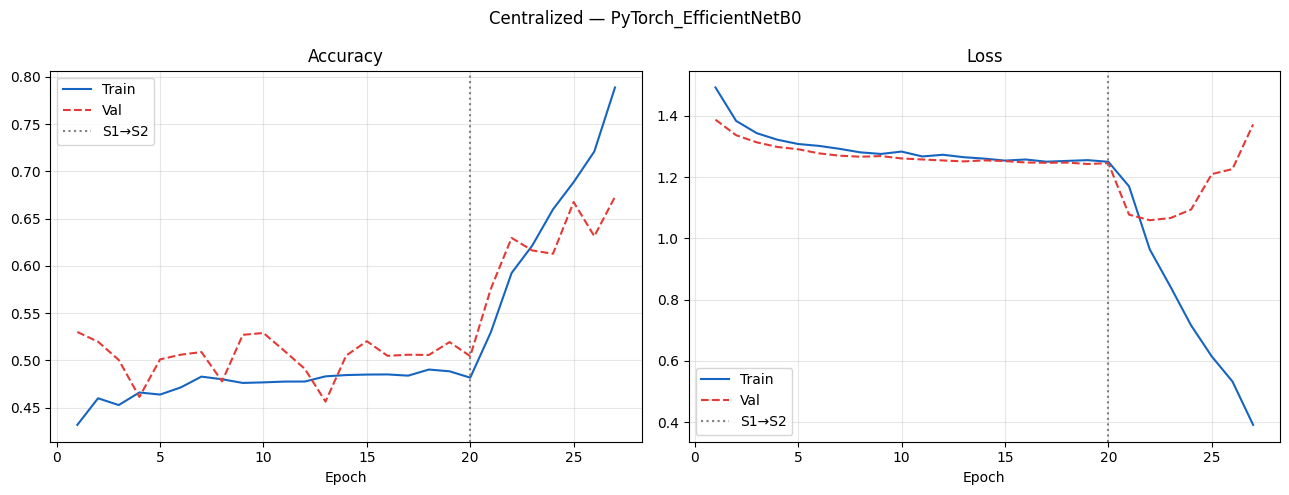

In [17]:
torch.save(model.state_dict(), f"{MDL_DIR}/{EXPERIMENT_NAME}_final.pt")
print(f"Saved: {MDL_DIR}/{EXPERIMENT_NAME}_final.pt")

s1_len = len(history_s1["train_loss"])
ep     = list(range(1, s1_len + len(history_s2["train_loss"]) + 1))
hist   = {
    "loss":         history_s1["train_loss"] + history_s2["train_loss"],
    "val_loss":     history_s1["val_loss"]   + history_s2["val_loss"],
    "accuracy":     history_s1["train_acc"]  + history_s2["train_acc"],
    "val_accuracy": history_s1["val_acc"]    + history_s2["val_acc"],
    "stage": ["s1"]*s1_len + ["s2"]*len(history_s2["train_loss"])
}
pd.DataFrame(hist).assign(epoch=ep).to_csv(f"{LOG_DIR}/training_history.csv", index=False)

fig, ax = plt.subplots(1,2,figsize=(13,5))
ax[0].plot(ep, hist["accuracy"],     label="Train", color="#1565C0")
ax[0].plot(ep, hist["val_accuracy"], label="Val",   color="#E53935", ls="--")
ax[0].axvline(s1_len, color="gray", ls=":", lw=1.5, label="S1→S2")
ax[0].set_title("Accuracy"); ax[0].legend(); ax[0].grid(alpha=.3); ax[0].set_xlabel("Epoch")

ax[1].plot(ep, hist["loss"],     label="Train", color="#1565C0")
ax[1].plot(ep, hist["val_loss"], label="Val",   color="#E53935", ls="--")
ax[1].axvline(s1_len, color="gray", ls=":", lw=1.5, label="S1→S2")
ax[1].set_title("Loss"); ax[1].legend(); ax[1].grid(alpha=.3); ax[1].set_xlabel("Epoch")

plt.suptitle(f"Centralized — {MODEL_NAME}"); plt.tight_layout()
plt.savefig(f"{FIG_DIR}/training_curves.png", dpi=300, bbox_inches="tight"); plt.show()

## 15. Predict Clean + Noisy

In [18]:
print("Predicting clean...")
yp_clean, yd_clean = predict(model, test_dl_clean)

print("Predicting noisy...")
yp_noisy, yd_noisy = predict(model, test_dl_noisy)

print(f"Clean preds: {yd_clean.shape} | Noisy preds: {yd_noisy.shape}")

Predicting clean...
Predicting noisy...
Clean preds: (7698,) | Noisy preds: (7698,)


## 16. Metrics + Robustness Drop

In [19]:
def metrics(yt, yp, yprob):
    a = accuracy_score(yt, yp)
    p,r,f,_ = precision_recall_fscore_support(yt, yp, average="macro", zero_division=0)
    yb = label_binarize(yt, classes=np.arange(NUM_CLASSES))
    try: au = roc_auc_score(yb, yprob, multi_class="ovr", average="macro")
    except: au = float("nan")
    q = cohen_kappa_score(yt, yp, weights="quadratic")
    return dict(accuracy=float(a), precision_macro=float(p), recall_macro=float(r),
                f1_macro=float(f), auc_roc=float(au), qwk=float(q))

MKEYS = ["accuracy","precision_macro","recall_macro","f1_macro","auc_roc","qwk"]
mc = metrics(y_test, yd_clean, yp_clean)
mn = metrics(y_test, yd_noisy, yp_noisy)

print(f"{'Metric':<18} {'Clean':>8} {'Noisy':>8} {'Drop':>8}")
print("-"*44)
rob = {}
for k in MKEYS:
    d = mc[k]-mn[k]; rob[f"drop_{k}"] = float(d)
    print(f"{k:<18} {mc[k]:>8.4f} {mn[k]:>8.4f} {d:>+8.4f}")

Metric                Clean    Noisy     Drop
--------------------------------------------
accuracy             0.6294   0.3549  +0.2745
precision_macro      0.4471   0.4984  -0.0512
recall_macro         0.5509   0.3266  +0.2243
f1_macro             0.4610   0.2106  +0.2504
auc_roc              0.8406   0.6927  +0.1479
qwk                  0.6717   0.1462  +0.5254


## 17. Per-Class Metrics

In [20]:
def per_class(yt, yp):
    p,r,f,s = precision_recall_fscore_support(yt, yp, labels=np.arange(NUM_CLASSES), zero_division=0)
    return pd.DataFrame({"class":np.arange(NUM_CLASSES),"name":CLASS_NAMES,
                          "precision":p,"recall":r,"f1":f,"support":s})
pc_c = per_class(y_test, yd_clean); pc_n = per_class(y_test, yd_noisy)
print("CLEAN:"); print(pc_c.to_string(index=False))
print("\nNOISY:"); print(pc_n.to_string(index=False))
pc_c.to_csv(f"{LOG_DIR}/per_class_clean.csv", index=False)
pc_n.to_csv(f"{LOG_DIR}/per_class_noisy.csv", index=False)

CLEAN:
 class          name  precision   recall       f1  support
     0         No DR   0.862291 0.739130 0.795975     5083
     1          Mild   0.136000 0.361702 0.197674      517
     2      Moderate   0.578736 0.357054 0.441638     1616
     3        Severe   0.220779 0.523077 0.310502      195
     4 Proliferative   0.437870 0.773519 0.559194      287

NOISY:
 class          name  precision   recall       f1  support
     0         No DR   0.825299 0.421011 0.557582     5083
     1          Mild   1.000000 0.003868 0.007707      517
     2      Moderate   0.325160 0.188738 0.238841     1616
     3        Severe   0.275862 0.082051 0.126482      195
     4 Proliferative   0.065498 0.937282 0.122440      287


## 18. Per-Client Breakdown

In [21]:
print(f"{'Client':<10} {'N':>5}  {'Acc_C':>7} {'Acc_N':>7} {'Drop':>7}  {'F1_C':>6} {'F1_N':>6}  {'QWK_C':>7} {'QWK_N':>7}")
print("-"*78)
pcc = {}
for cl in CLIENT_NAMES:
    m = src_test == cl
    if not m.any(): continue
    mc_ = metrics(y_test[m], yd_clean[m], yp_clean[m])
    mn_ = metrics(y_test[m], yd_noisy[m], yp_noisy[m])
    pcc[cl] = {"n":int(m.sum()),"clean":mc_,"noisy":mn_}
    print(f"{cl:<10} {m.sum():>5,}  {mc_['accuracy']:>7.4f} {mn_['accuracy']:>7.4f} "
          f"{mc_['accuracy']-mn_['accuracy']:>+7.4f}  "
          f"{mc_['f1_macro']:>6.4f} {mn_['f1_macro']:>6.4f}  "
          f"{mc_['qwk']:>7.4f} {mn_['qwk']:>7.4f}")

Client         N    Acc_C   Acc_N    Drop    F1_C   F1_N    QWK_C   QWK_N
------------------------------------------------------------------------------
DDR        1,879   0.6754  0.4226 +0.2528  0.5194 0.3113   0.7622  0.3004
EyePACS    5,269   0.6119  0.3388 +0.2731  0.4112 0.1666   0.5405  0.0826
APTOS        550   0.6400  0.2782 +0.3618  0.4691 0.1722   0.7899  0.2874


## 19. Confusion Matrices

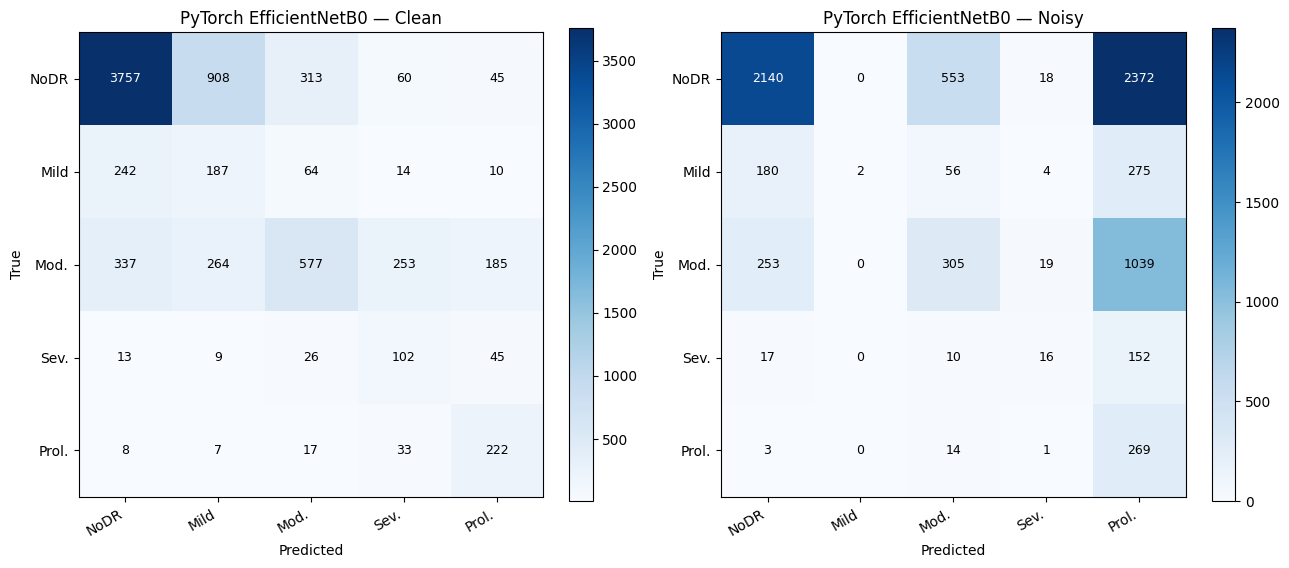

In [22]:
SN = ["NoDR","Mild","Mod.","Sev.","Prol."]
cm_c = confusion_matrix(y_test, yd_clean, labels=np.arange(NUM_CLASSES))
cm_n = confusion_matrix(y_test, yd_noisy, labels=np.arange(NUM_CLASSES))

fig, ax = plt.subplots(1,2,figsize=(13,6))
for a,cm,title in [(ax[0],cm_c,"Clean"),(ax[1],cm_n,"Noisy")]:
    im = a.imshow(cm, cmap="Blues"); plt.colorbar(im, ax=a, fraction=.046)
    a.set_xticks(range(NUM_CLASSES)); a.set_yticks(range(NUM_CLASSES))
    a.set_xticklabels(SN, rotation=30, ha="right"); a.set_yticklabels(SN)
    th = cm.max()/2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            a.text(j,i,str(cm[i,j]),ha="center",va="center",fontsize=9,
                   color="white" if cm[i,j]>th else "black")
    a.set_xlabel("Predicted"); a.set_ylabel("True")
    a.set_title(f"PyTorch EfficientNetB0 — {title}")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/confusion_matrices.png", dpi=300, bbox_inches="tight"); plt.show()

## 20. ROC Curves

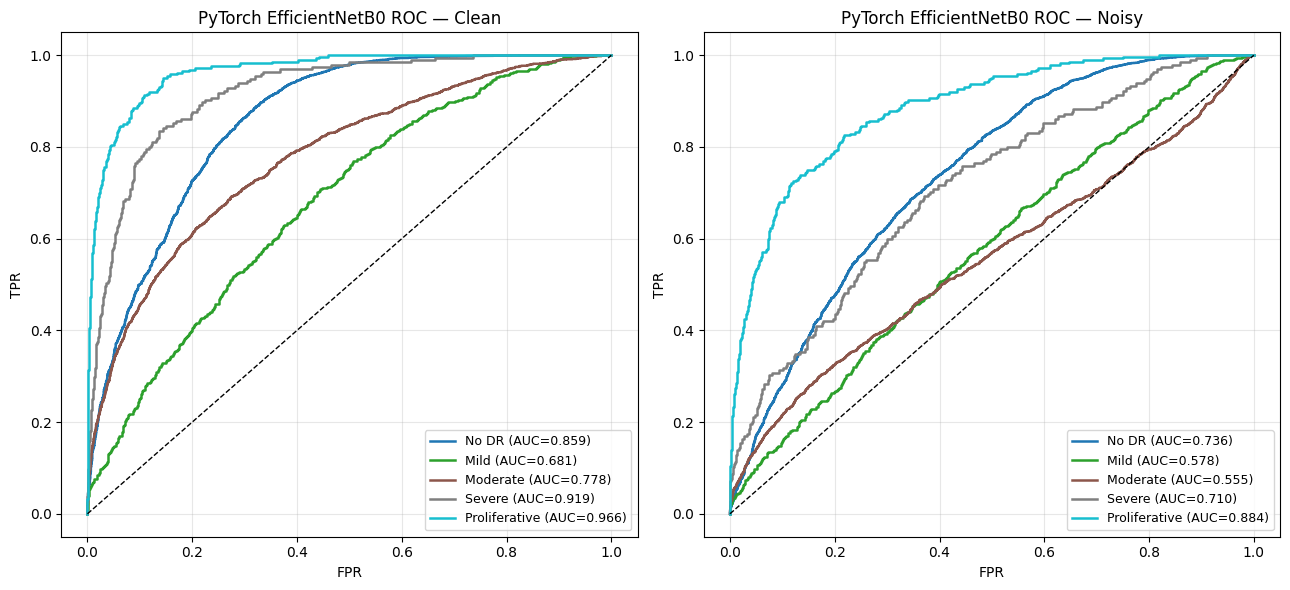

In [23]:
yb   = label_binarize(y_test, classes=np.arange(NUM_CLASSES))
COLS = plt.cm.tab10(np.linspace(0,1,NUM_CLASSES))
fig, ax = plt.subplots(1,2,figsize=(13,6))
for a,yprob,title in [(ax[0],yp_clean,"Clean"),(ax[1],yp_noisy,"Noisy")]:
    for i in range(NUM_CLASSES):
        fpr,tpr,_ = roc_curve(yb[:,i], yprob[:,i])
        a.plot(fpr,tpr,color=COLS[i],lw=1.8,label=f"{CLASS_NAMES[i]} (AUC={auc(fpr,tpr):.3f})")
    a.plot([0,1],[0,1],"k--",lw=1); a.set_xlabel("FPR"); a.set_ylabel("TPR")
    a.set_title(f"PyTorch EfficientNetB0 ROC — {title}")
    a.legend(fontsize=9, loc="lower right"); a.grid(alpha=.3)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/roc_curves.png", dpi=300, bbox_inches="tight"); plt.show()

## 21. Robustness Drop Visualization

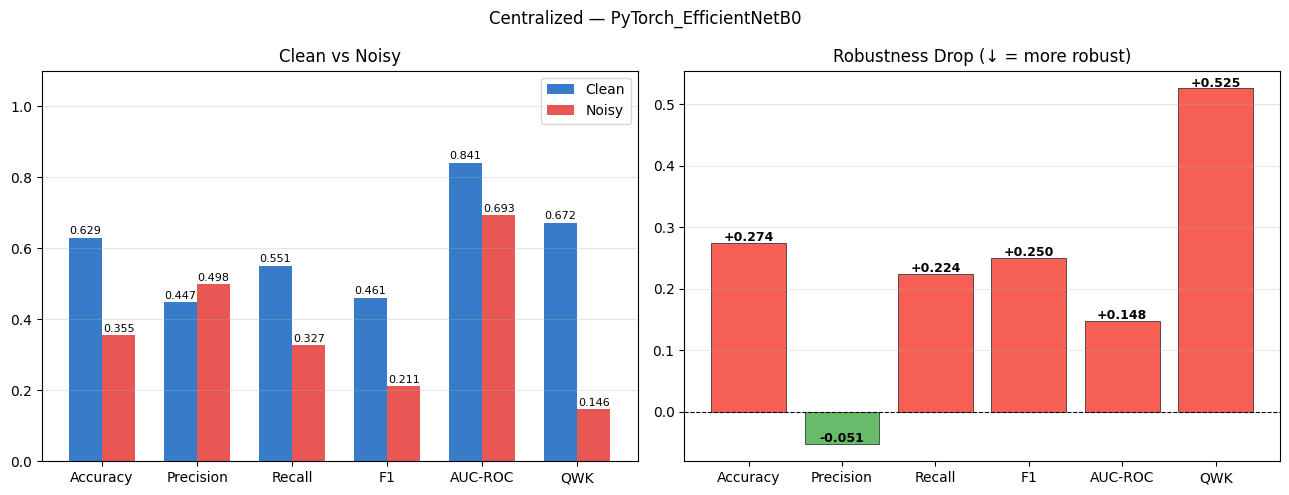

In [24]:
MLABELS = ["Accuracy","Precision","Recall","F1","AUC-ROC","QWK"]
cv=[mc[k] for k in MKEYS]; nv=[mn[k] for k in MKEYS]; dv=[rob[f"drop_{k}"] for k in MKEYS]
x=np.arange(len(MLABELS)); w=.35

fig, ax = plt.subplots(1,2,figsize=(13,5))
ax[0].bar(x-w/2,cv,w,label="Clean",color="#1565C0",alpha=.85)
ax[0].bar(x+w/2,nv,w,label="Noisy",color="#E53935",alpha=.85)
for i,(a_,b_) in enumerate(zip(cv,nv)):
    ax[0].text(i-w/2,a_+.01,f"{a_:.3f}",ha="center",fontsize=8)
    ax[0].text(i+w/2,b_+.01,f"{b_:.3f}",ha="center",fontsize=8)
ax[0].set_xticks(x); ax[0].set_xticklabels(MLABELS); ax[0].set_ylim(0,1.1)
ax[0].set_title("Clean vs Noisy"); ax[0].legend(); ax[0].grid(axis="y",alpha=.3)

clrs=["#4CAF50" if d<=.05 else "#FFC107" if d<=.1 else "#F44336" for d in dv]
ax[1].bar(x,dv,color=clrs,alpha=.85,edgecolor="black",lw=.5)
for i,d in enumerate(dv): ax[1].text(i,d+.003,f"{d:+.3f}",ha="center",fontsize=9,fontweight="bold")
ax[1].set_xticks(x); ax[1].set_xticklabels(MLABELS)
ax[1].set_title("Robustness Drop (↓ = more robust)")
ax[1].axhline(0,color="k",lw=.8,ls="--"); ax[1].grid(axis="y",alpha=.3)
plt.suptitle(f"Centralized — {MODEL_NAME}"); plt.tight_layout()
plt.savefig(f"{FIG_DIR}/robustness_drop.png", dpi=300, bbox_inches="tight"); plt.show()

## 22. Save Results + Summary

In [25]:
res = {
    "experiment": EXPERIMENT_NAME, "model": MODEL_NAME,
    "framework": "PyTorch", "paradigm": "Centralized",
    "n_train": int(len(y_train)), "n_val": int(len(y_val)), "n_test": int(len(y_test)),
    "metrics_clean": mc, "metrics_noisy": mn, "robustness_drop": rob,
    "per_client": pcc,
    "confusion_matrix_clean": cm_c.tolist(), "confusion_matrix_noisy": cm_n.tolist(),
    "config": dict(seed=SEED, noisy_test_seed=NOISY_TEST_SEED, batch=BATCH_SIZE,
                   lr=LR, epochs_s1=EPOCHS_S1, epochs_s2=EPOCHS_S2,
                   unfreeze_n=UNFREEZE_N, dropout=DROPOUT,
                   imagenet_mean=IMAGENET_MEAN, imagenet_std=IMAGENET_STD)
}
with open(f"{LOG_DIR}/results.json","w") as f: json.dump(res,f,indent=2)

row = {"experiment":EXPERIMENT_NAME,"paradigm":"Centralized","model":MODEL_NAME,"framework":"PyTorch"}
row.update({f"clean_{k}":mc[k] for k in MKEYS})
row.update({f"noisy_{k}":mn[k] for k in MKEYS})
row.update(rob)
pd.DataFrame([row]).to_csv(f"{LOG_DIR}/summary_row.csv", index=False)
print(f"Saved to: {RES}")

print("\n"+"="*60)
print(f"  EXP1 CENTRALIZED (PyTorch EfficientNetB0) — DONE")
print("="*60)
print(f"  CLEAN  | Acc:{mc['accuracy']:.4f}  F1:{mc['f1_macro']:.4f}  AUC:{mc['auc_roc']:.4f}  QWK:{mc['qwk']:.4f}")
print(f"  NOISY  | Acc:{mn['accuracy']:.4f}  F1:{mn['f1_macro']:.4f}  AUC:{mn['auc_roc']:.4f}  QWK:{mn['qwk']:.4f}")
print(f"  DROP   | Acc:{rob['drop_accuracy']:+.4f}  F1:{rob['drop_f1_macro']:+.4f}  AUC:{rob['drop_auc_roc']:+.4f}  QWK:{rob['drop_qwk']:+.4f}")
print("="*60)
print("\n  Compare hasil ini sama TF EfficientNetB0 (effnet_exp1_centralized.ipynb)")
print("  Key diff: PyTorch pakai ImageNet mean/std norm, TF pakai internal rescaling")

Saved to: /content/drive/MyDrive/Binus/Semester_4/Research_Methodology/Result/PyTorch_EfficientNetB0/exp1_centralized

  EXP1 CENTRALIZED (PyTorch EfficientNetB0) — DONE
  CLEAN  | Acc:0.6294  F1:0.4610  AUC:0.8406  QWK:0.6717
  NOISY  | Acc:0.3549  F1:0.2106  AUC:0.6927  QWK:0.1462
  DROP   | Acc:+0.2745  F1:+0.2504  AUC:+0.1479  QWK:+0.5254

  Compare hasil ini sama TF EfficientNetB0 (effnet_exp1_centralized.ipynb)
  Key diff: PyTorch pakai ImageNet mean/std norm, TF pakai internal rescaling
